<a href="https://www.kaggle.com/code/lalit7881/superstore-sales-analytics-dataset-eda?scriptVersionId=314016857" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/discount_analysis.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/data_dictionary.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/superstore_sample_100rows.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/regional_performance.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/statistical_summary.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/correlation_matrix.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/superstore_cleaned_complete.csv
/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/supe

## Loading dataset

In [2]:
# Load main dataset
df = pd.read_csv("/kaggle/input/datasets/nafeesalmahadi/superstore-sales-analytics-dataset-2026/superstore_analytics_output/superstore_cleaned_complete.csv")

# View basic info
print("Shape:", df.shape)
df.head()

Shape: (51290, 32)


,category,city,country,customer_id,customer_name,discount,market,column,order_date,order_id,...,sub_category,order_year,order_month,order_quarter,order_day_of_week,is_weekend,order_week,discount_bin,profit_margin,sales_per_unit
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,Us,1,2011-01-07,CA-2011-130813,...,Paper,2011,1,1,4,0,1,0-5%,49.11,6.33
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,Us,1,2011-01-21,CA-2011-148614,...,Paper,2011,1,1,4,0,3,0-5%,48.91,9.50
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,2011-08-05,CA-2011-118962,...,Paper,2011,8,3,4,0,31,0-5%,46.87,7.00
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,2011-08-05,CA-2011-118962,...,Paper,2011,8,3,4,0,31,0-5%,47.98,55.50
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,Us,1,2011-09-29,CA-2011-146969,...,Paper,2011,9,3,3,0,39,0-5%,51.84,6.00


In [3]:
# Column names
print(df.columns)

# Data types
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'column', 'order_date', 'order_id',
       'order_priority', 'product_id', 'product_name', 'profit', 'quantity',
       'region', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost',
       'state', 'sub_category', 'order_year', 'order_month', 'order_quarter',
       'order_day_of_week', 'is_weekend', 'order_week', 'discount_bin',
       'profit_margin', 'sales_per_unit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           51290 non-null  object 
 1   city               51290 non-null  object 
 2   country            51290 non-null  object 
 3   customer_id        51290 non-null  object 
 4   customer_name      51290 non-null  object 
 5   discount           51290 non-null  float64


category             0
city                 0
country              0
customer_id          0
customer_name        0
discount             0
market               0
column               0
order_date           0
order_id             0
order_priority       0
product_id           0
product_name         0
profit               0
quantity             0
region               0
sales                0
segment              0
ship_date            0
ship_mode            0
shipping_cost        0
state                0
sub_category         0
order_year           0
order_month          0
order_quarter        0
order_day_of_week    0
is_weekend           0
order_week           0
discount_bin         0
profit_margin        0
sales_per_unit       0
dtype: int64

In [4]:
# Convert date column (if exists)
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'])

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values (example strategy)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

## EDA

Shape: (51290, 32)

Columns:
 Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'column', 'order_date', 'order_id',
       'order_priority', 'product_id', 'product_name', 'profit', 'quantity',
       'region', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost',
       'state', 'sub_category', 'order_year', 'order_month', 'order_quarter',
       'order_day_of_week', 'is_weekend', 'order_week', 'discount_bin',
       'profit_margin', 'sales_per_unit'],
      dtype='object')

Missing Values:
 category             0
city                 0
country              0
customer_id          0
customer_name        0
discount             0
market               0
column               0
order_date           0
order_id             0
order_priority       0
product_id           0
product_name         0
profit               0
quantity             0
region               0
sales                0
segment              0
ship_date            0
ship_mod

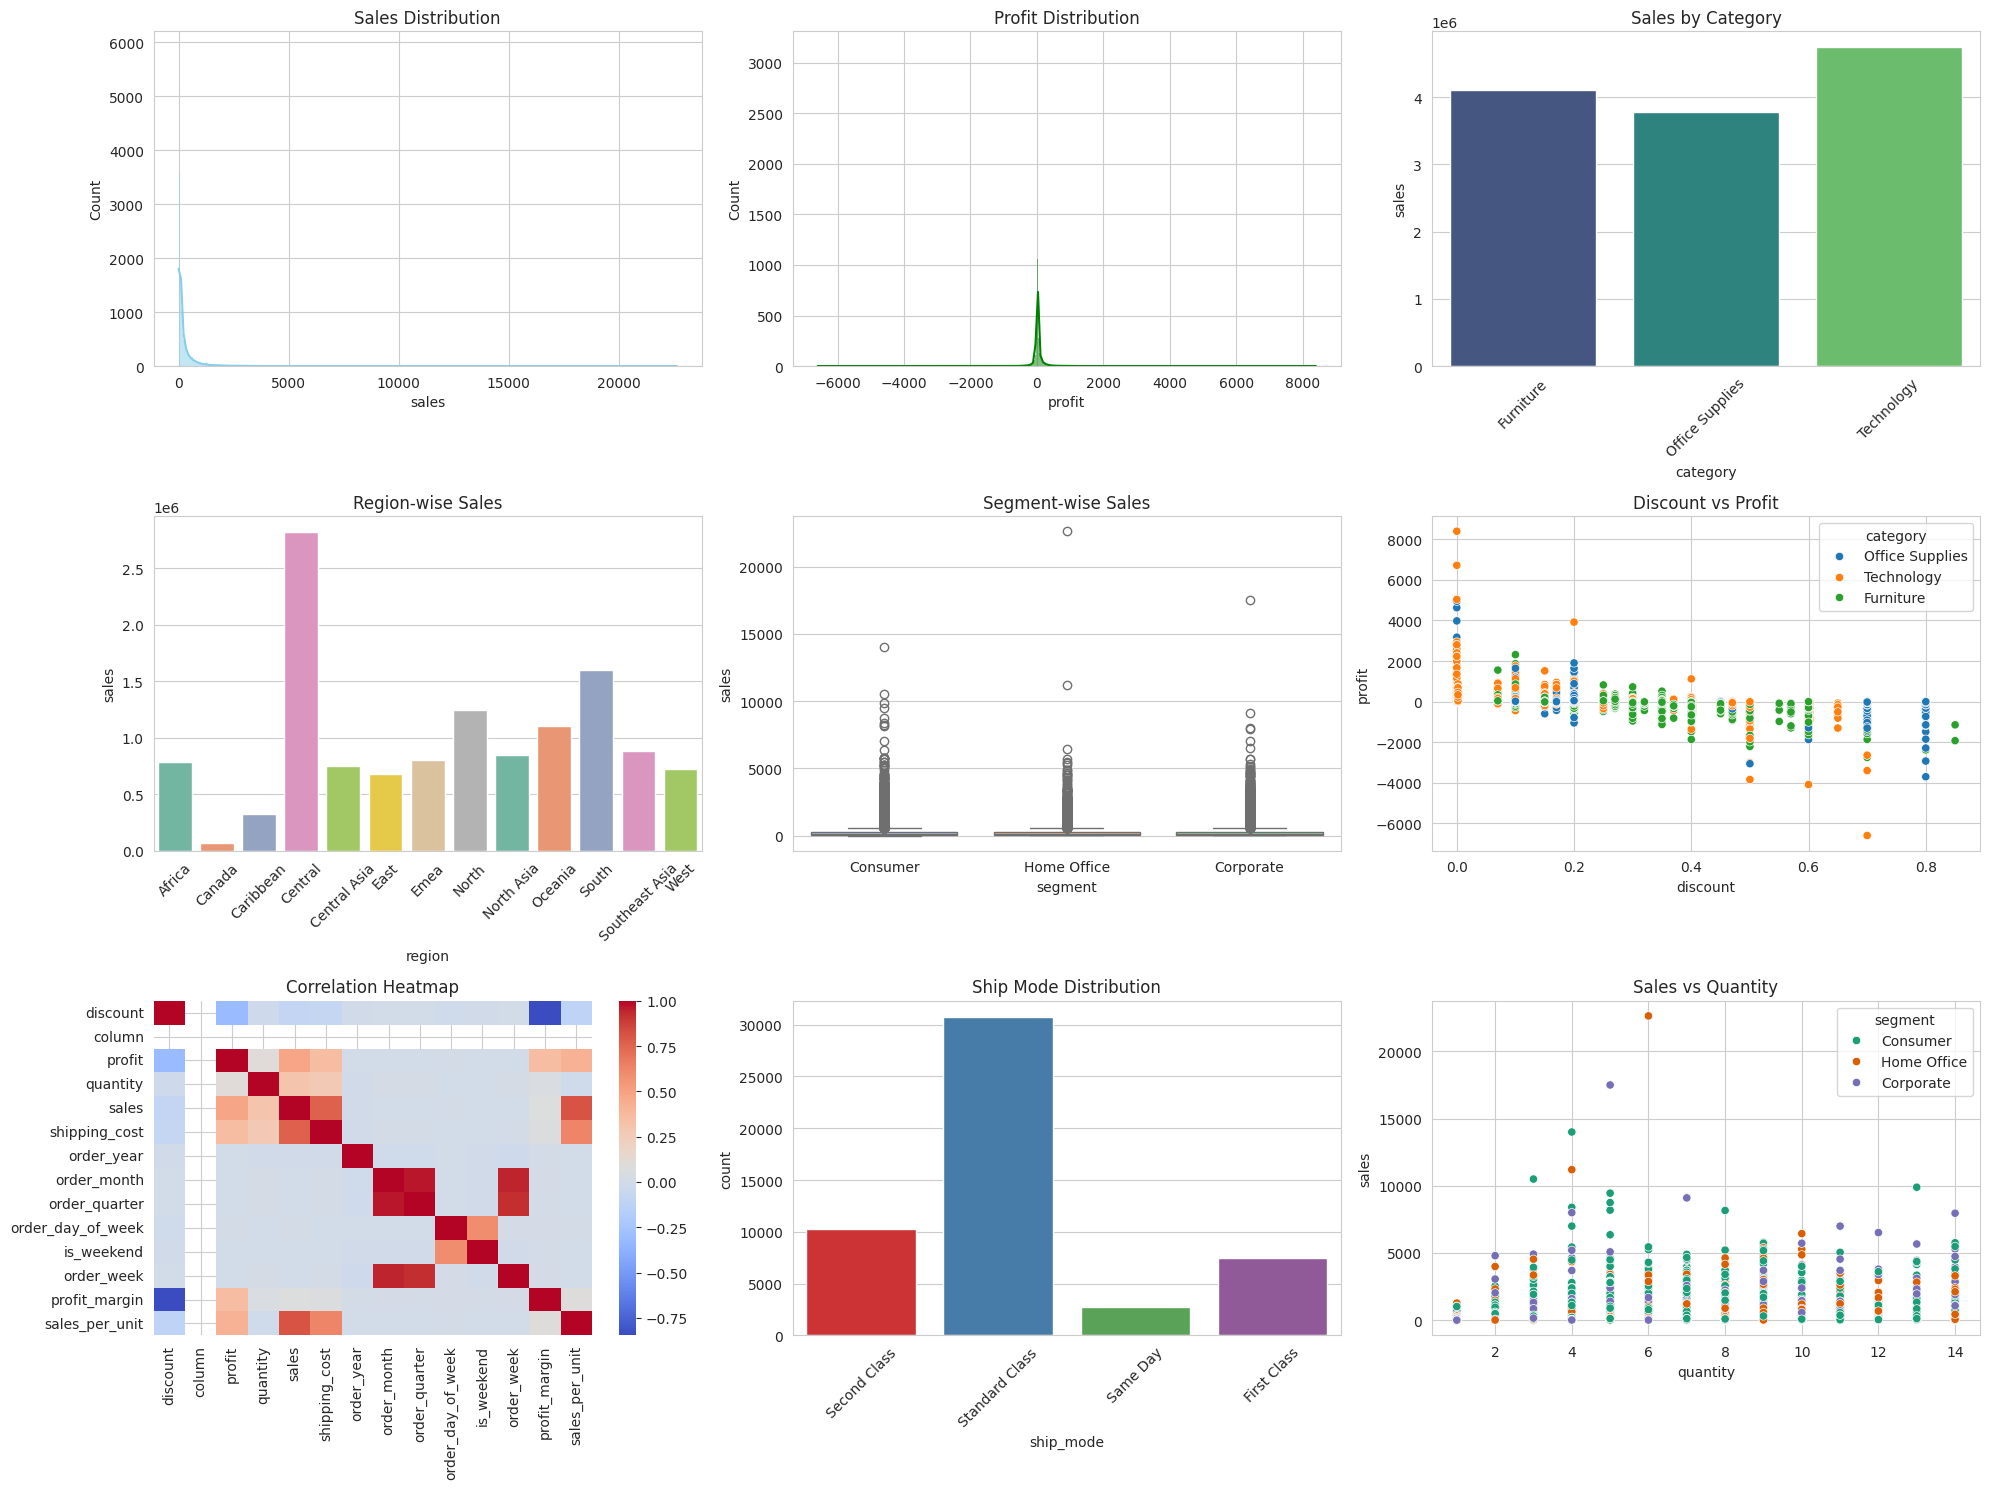

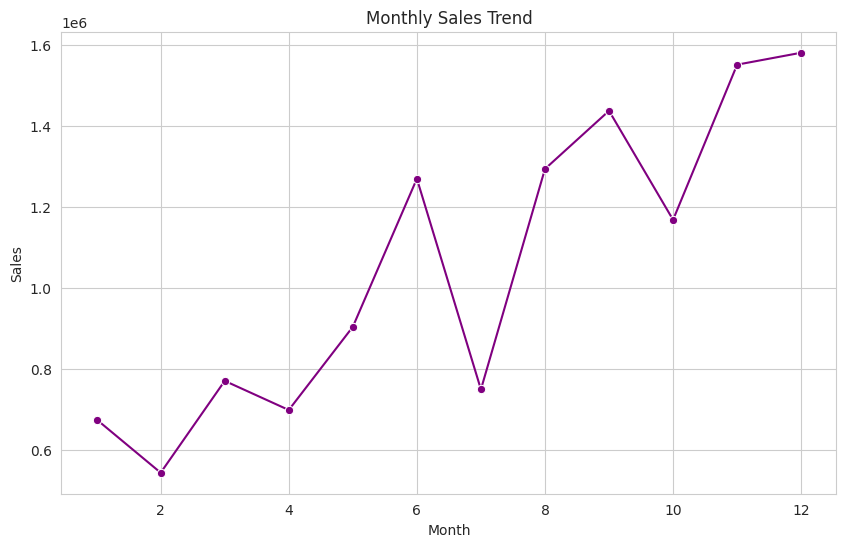

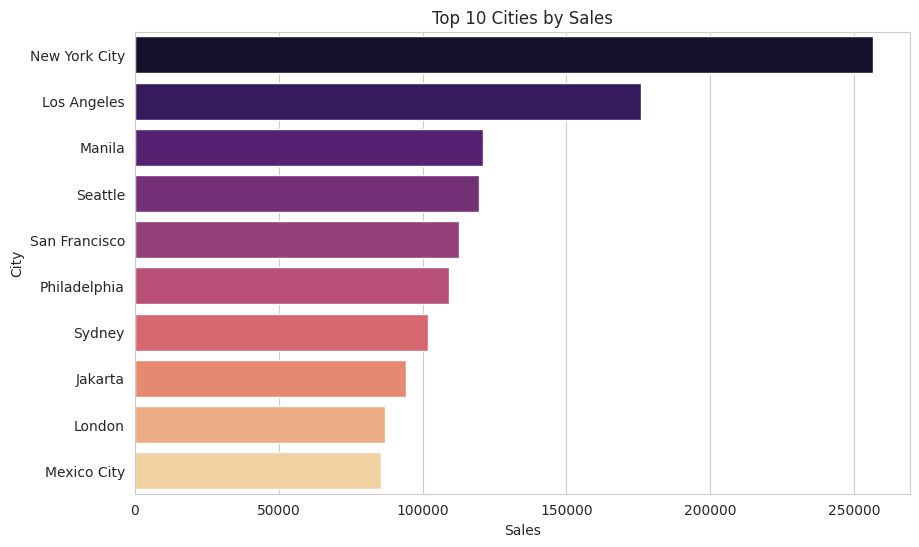

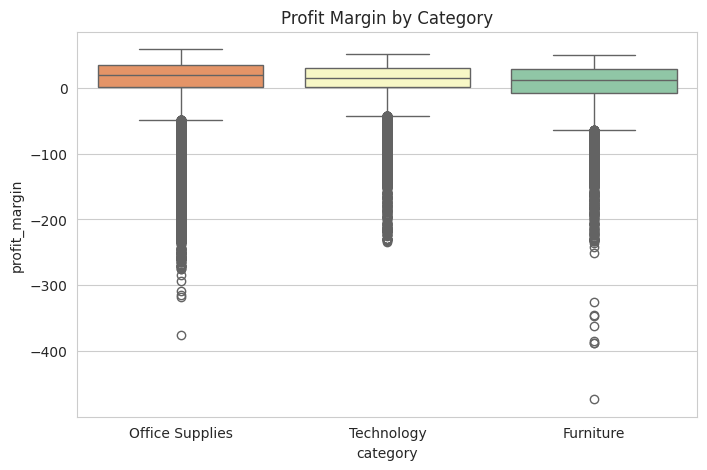

In [5]:
# 3. Basic Info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

# 4. Convert Dates
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

# 5. Feature Check / Create (if needed)
if 'sales_per_unit' not in df.columns:
    df['sales_per_unit'] = df['sales'] / df['quantity']

# 6. Styling
sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))

# ==========================================
# VISUALIZATIONS
# ==========================================

# 1. Sales Distribution
plt.subplot(3,3,1)
sns.histplot(df['sales'], kde=True, color='skyblue')
plt.title("Sales Distribution")

# 2. Profit Distribution
plt.subplot(3,3,2)
sns.histplot(df['profit'], kde=True, color='green')
plt.title("Profit Distribution")

# 3. Category-wise Sales
plt.subplot(3,3,3)
cat_sales = df.groupby('category')['sales'].sum().reset_index()
sns.barplot(x='category', y='sales', data=cat_sales, palette='viridis')
plt.xticks(rotation=45)
plt.title("Sales by Category")

# 4. Region-wise Sales
plt.subplot(3,3,4)
reg_sales = df.groupby('region')['sales'].sum().reset_index()
sns.barplot(x='region', y='sales', data=reg_sales, palette='Set2')
plt.xticks(rotation=45)
plt.title("Region-wise Sales")

# 5. Segment-wise Sales (Boxplot)
plt.subplot(3,3,5)
sns.boxplot(x='segment', y='sales', data=df, palette='pastel')
plt.title("Segment-wise Sales")

# 6. Discount vs Profit
plt.subplot(3,3,6)
sns.scatterplot(x='discount', y='profit', hue='category', data=df, palette='tab10')
plt.title("Discount vs Profit")

# 7. Correlation Heatmap (FIXED)
plt.subplot(3,3,7)
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, cbar=True)
plt.title("Correlation Heatmap")

# 8. Ship Mode Distribution
plt.subplot(3,3,8)
sns.countplot(x='ship_mode', data=df, palette='Set1')
plt.xticks(rotation=45)
plt.title("Ship Mode Distribution")

# 9. Sales vs Quantity
plt.subplot(3,3,9)
sns.scatterplot(x='quantity', y='sales', hue='segment', data=df, palette='Dark2')
plt.title("Sales vs Quantity")

# Layout Fix
plt.tight_layout()
plt.show()


# 10. Monthly Sales Trend
plt.figure(figsize=(10,6))
monthly_sales = df.groupby('order_month')['sales'].sum().reset_index()

sns.lineplot(x='order_month', y='sales', data=monthly_sales, marker='o', color='purple')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# 11. Top 10 Cities by Sales
plt.figure(figsize=(10,6))
top_cities = df.groupby('city')['sales'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='magma')
plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City")
plt.show()

# 12. Profit Margin by Category
plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='profit_margin', data=df, palette='Spectral')
plt.title("Profit Margin by Category")
plt.show()

## Feture engineering


===== Logistic Regression =====
Accuracy: 0.9193799961006044
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2642
           1       0.92      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258


===== Decision Tree =====
Accuracy: 0.9234743614739716
              precision    recall  f1-score   support

           0       0.92      0.77      0.84      2642
           1       0.92      0.98      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.92      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258


===== Random Forest =====
Accuracy: 0.9185026320920258
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2642
           1       0.92      0.97      0.95      7616

    accu

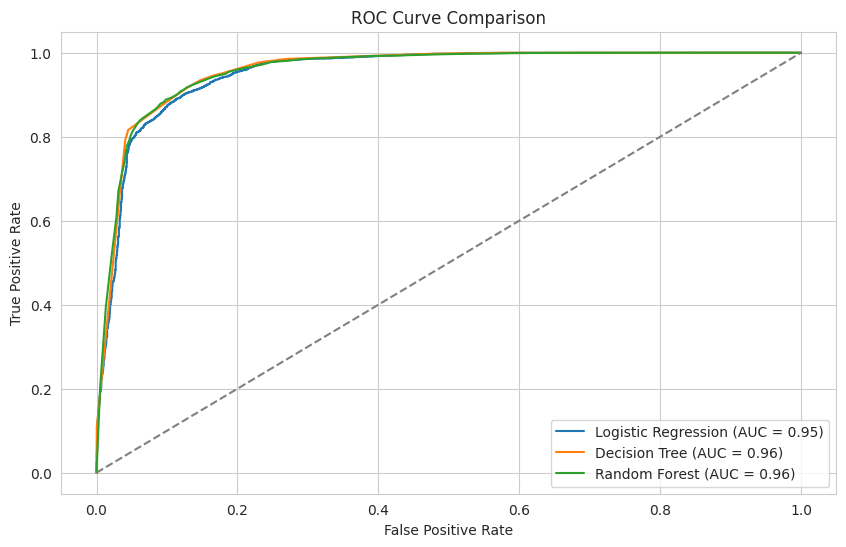


=== Model Accuracy Comparison ===
Logistic Regression: 0.9194
Decision Tree: 0.9235
Random Forest: 0.9185


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# 3. Create Target Variable (Binary Classification)
# Profitable (1) if profit > 0 else 0
df['is_profitable'] = (df['profit'] > 0).astype(int)

# 4. Drop leakage columns (VERY IMPORTANT)
# profit is used to create target → REMOVE IT
drop_cols = ['profit', 'profit_margin']
X = df.drop(columns=drop_cols + ['is_profitable'])
y = df['is_profitable']

# 5. Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove IDs (not useful for ML)
id_cols = ['order_id','customer_id','product_id','customer_name','product_name']
categorical_cols = [col for col in categorical_cols if col not in id_cols]

# Drop ID columns from X
X = X.drop(columns=id_cols)

# 6. Train-Test Split (before preprocessing → NO LEAKAGE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# ==========================================
# MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store results
results = {}

# ==========================================
# TRAIN + EVALUATE
# ==========================================

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Create pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot ROC Curve
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================================
# FINAL RESULTS
# ==========================================

print("\n=== Model Accuracy Comparison ===")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

## Thank you..pls upvote!!!!!!!!!!!!